In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

In [3]:
#LOad the numpy arrays saved by data_transformation.py
# Load the numpy arrays saved by data_transformation.py
train_arr = np.load("../artifacts/train_arr.npy")
test_arr  = np.load("../artifacts/test_arr.npy")

# Split features and target
X_train = train_arr[:, :-1]
y_train = train_arr[:, -1]

X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Train class distribution:", np.unique(y_train, return_counts=True))
print("Test class distribution :", np.unique(y_test, return_counts=True))

X_train shape: (8276, 45)
X_test shape : (1409, 45)
Train class distribution: (array([0., 1.]), array([4138, 4138]))
Test class distribution : (array([0., 1.]), array([1036,  373]))


In [4]:
models = {
    "Logistic Regression":    LogisticRegression(max_iter=1000),
    "Decision Tree":          DecisionTreeClassifier(),
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":      GradientBoostingClassifier(random_state=42),
    "XGBoost":                XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "CatBoost":               CatBoostClassifier(verbose=0, random_state=42),
    "SVM":                    SVC(probability=True),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {"F1": round(f1, 4), "ROC-AUC": round(auc, 4)}
    print(f"{name:25s} → F1: {f1:.4f} | AUC: {auc:.4f}")

Logistic Regression       → F1: 0.6472 | AUC: 0.8613
Decision Tree             → F1: 0.5131 | AUC: 0.6688
Random Forest             → F1: 0.5785 | AUC: 0.8318
Gradient Boosting         → F1: 0.6481 | AUC: 0.8584
XGBoost                   → F1: 0.6038 | AUC: 0.8387
CatBoost                  → F1: 0.6316 | AUC: 0.8554
SVM                       → F1: 0.6251 | AUC: 0.8419


In [5]:
results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print(results_df)

                         F1  ROC-AUC
Gradient Boosting    0.6481   0.8584
Logistic Regression  0.6472   0.8613
CatBoost             0.6316   0.8554
SVM                  0.6251   0.8419
XGBoost              0.6038   0.8387
Random Forest        0.5785   0.8318
Decision Tree        0.5131   0.6688


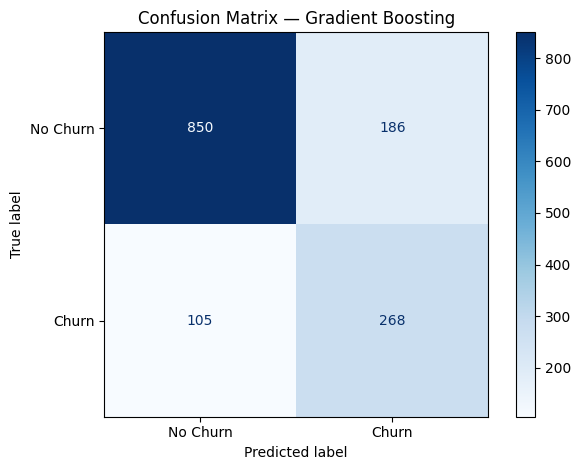


Best Model: Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.89      0.82      0.85      1036
       Churn       0.59      0.72      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



In [6]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("../artifacts/confusion_matrix.png")
plt.show()

print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))